# Mini Projet — Gestion du déséquilibre de classes
## Étape 1 : Analyse Exploratoire du Corpus TWIFL
**Module :** Machine Learning | **Enseignante :** Dr. Soraya Cheriguene  
**Université :** USDB — Master 1 SD & TAL | **Année :** 2025–2026

## 1.0 Installation des dépendances

In [8]:
!pip install datasets pandas matplotlib seaborn wordcloud emoji langdetect


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 1.1 Chargement du corpus TWIFL

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import re
import emoji
from datasets import load_dataset
from wordcloud import WordCloud
from collections import Counter

warnings.filterwarnings('ignore')

# Seed global pour la reproductibilité
SEED = 42
np.random.seed(SEED)

# Style des graphiques
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Bibliothèques chargées avec succès.")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/miniconda3/lib/python3.9/sit

Bibliothèques chargées avec succès.


In [10]:
# Chargement du dataset TWIFL depuis HuggingFace
print("Chargement du corpus TWIFL depuis HuggingFace...")
dataset = load_dataset("arbml/Twifil")

print("\nStructure du dataset :")
print(dataset)

# Afficher les splits disponibles
print("\nSplits disponibles :", list(dataset.keys()))

Chargement du corpus TWIFL depuis HuggingFace...


Repo card metadata block was not found. Setting CardData to empty.



Structure du dataset :
DatasetDict({
    train: Dataset({
        features: ['ID', 'Code', 'Post', 'lang', 'Created At', 'Followers Count', 'Profile Link Color', 'Geo Enabled', 'Screen Name', 'Name', 'Profile Lang', 'Polarity', 'Polarity Class', 'User Age', 'Emotion', 'Platform'],
        num_rows: 6000
    })
})

Splits disponibles : ['train']


In [11]:
# Conversion en DataFrame pandas — on fusionne tous les splits disponibles
dfs = []
for split_name, split_data in dataset.items():
    df_split = split_data.to_pandas()
    df_split['split_origin'] = split_name
    dfs.append(df_split)

df = pd.concat(dfs, ignore_index=True)

print(f"Nombre total de tweets : {len(df)}")
print(f"\nColonnes disponibles : {list(df.columns)}")
print("\nAperçu des premières lignes :")
df.head()

Nombre total de tweets : 6000

Colonnes disponibles : ['ID', 'Code', 'Post', 'lang', 'Created At', 'Followers Count', 'Profile Link Color', 'Geo Enabled', 'Screen Name', 'Name', 'Profile Lang', 'Polarity', 'Polarity Class', 'User Age', 'Emotion', 'Platform', 'split_origin']

Aperçu des premières lignes :


,ID,Code,Post,lang,Created At,Followers Count,Profile Link Color,Geo Enabled,Screen Name,Name,Profile Lang,Polarity,Polarity Class,User Age,Emotion,Platform,split_origin
0,1,9.5283479986508e+17,@gamehacker080 @WaellAmeer @Kempa2010 @omeralb...,ar,Mon Jan 15 09:28:13 +0000 2018,215,0084B4,1,JackoTyga,Amine Jacko,fr,"3,43",Positive,26.0,nan,Twitter,train
1,2,9.5283475039334e+17,@arar12332095361 صل الله عليه و سلم,ar,Mon Jan 15 09:28:01 +0000 2018,1682,19CF86,1,aminoooo_amine,Amine Bourahla,fr,"7,14",Positive,26.0,nan,Twitter,train
2,3,9.5283463826695e+17,@SRKFC1 @iamsrk @gaurikhan 💖💖💖💖💖💖 https://t.co...,und,Mon Jan 15 09:27:35 +0000 2018,114,1DA1F2,1,FoufaKiri,Foufa kiri,fr,"3,33",Positive,nan,nan,Twitter,train
3,4,9.5283457943348e+17,.@realDonaldTrump YOU did this you started it!...,en,Mon Jan 15 09:27:21 +0000 2018,5367,E81C4F,1,Spartanise,Spartanise,en,"-6,29",Negative,nan,nan,Twitter,train
4,5,9.5283405417663e+17,"وقال: "" ... وعليهم *أَنْ يكونوا على يقظةٍ* مِن...",ar,Mon Jan 15 09:25:15 +0000 2018,135,1DA1F2,1,GhanayK,أبو العباس كريم,ar,"-2,71",Negative,nan,nan,Twitter,train


In [12]:
# Informations générales sur le dataset
print("=" * 50)
print("INFORMATIONS GÉNÉRALES SUR LE CORPUS")
print("=" * 50)
print(df.info())
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())
print("\nValeurs uniques de la colonne cible 'Polarity Class' :")
print(df['Polarity Class'].unique())

INFORMATIONS GÉNÉRALES SUR LE CORPUS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  6000 non-null   object
 1   Code                6000 non-null   object
 2   Post                6000 non-null   object
 3   lang                6000 non-null   object
 4   Created At          6000 non-null   object
 5   Followers Count     6000 non-null   object
 6   Profile Link Color  6000 non-null   object
 7   Geo Enabled         6000 non-null   object
 8   Screen Name         6000 non-null   object
 9   Name                6000 non-null   object
 10  Profile Lang        6000 non-null   object
 11  Polarity            6000 non-null   object
 12  Polarity Class      6000 non-null   object
 13  User Age            6000 non-null   object
 14  Emotion             6000 non-null   object
 15  Platform            6000 non-null  

## 1.2 Analyse de la variable cible (Polarity Class)

In [13]:
# Vérification de l'absence de valeurs inattendues dans Polarity Class
CLASSES_ATTENDUES = {'Positive', 'Negative', 'Neutral'}
classes_presentes = set(df['Polarity Class'].dropna().unique())
valeurs_inattendues = classes_presentes - CLASSES_ATTENDUES

if valeurs_inattendues:
    print(f"⚠️  Valeurs inattendues détectées : {valeurs_inattendues}")
else:
    print("✅  Aucune valeur inattendue dans 'Polarity Class'.")

# Suppression des lignes sans étiquette de polarité
df_clean = df.dropna(subset=['Polarity Class']).copy()
print(f"\nTweets conservés après suppression des NaN : {len(df_clean)} / {len(df)}")

✅  Aucune valeur inattendue dans 'Polarity Class'.

Tweets conservés après suppression des NaN : 6000 / 6000


In [14]:
# Calcul de la distribution des classes
class_counts = df_clean['Polarity Class'].value_counts()
class_pcts   = df_clean['Polarity Class'].value_counts(normalize=True) * 100

print("Distribution des classes :")
print("─" * 40)
for cls in class_counts.index:
    print(f"  {cls:<12} : {class_counts[cls]:>5} tweets  ({class_pcts[cls]:.1f}%)")
print("─" * 40)
print(f"  TOTAL        : {class_counts.sum():>5} tweets")

# Ratio de déséquilibre
max_class = class_counts.max()
min_class = class_counts.min()
imbalance_ratio = max_class / min_class

print(f"\nClasse majoritaire : {class_counts.idxmax()} ({max_class} exemples)")
print(f"Classe minoritaire : {class_counts.idxmin()} ({min_class} exemples)")
print(f"Ratio de déséquilibre : {imbalance_ratio:.2f}x")

# Interprétation
if imbalance_ratio >= 5:
    niveau = "FORTEMENT déséquilibré"
elif imbalance_ratio >= 2:
    niveau = "MODÉRÉMENT déséquilibré"
else:
    niveau = "FAIBLEMENT déséquilibré"
print(f"\n→ Conclusion : le corpus est {niveau} (ratio = {imbalance_ratio:.2f}).")

Distribution des classes :
────────────────────────────────────────
  Positive     :  2864 tweets  (47.7%)
  Negative     :  1773 tweets  (29.5%)
  Neutral      :  1363 tweets  (22.7%)
────────────────────────────────────────
  TOTAL        :  6000 tweets

Classe majoritaire : Positive (2864 exemples)
Classe minoritaire : Neutral (1363 exemples)
Ratio de déséquilibre : 2.10x

→ Conclusion : le corpus est MODÉRÉMENT déséquilibré (ratio = 2.10).


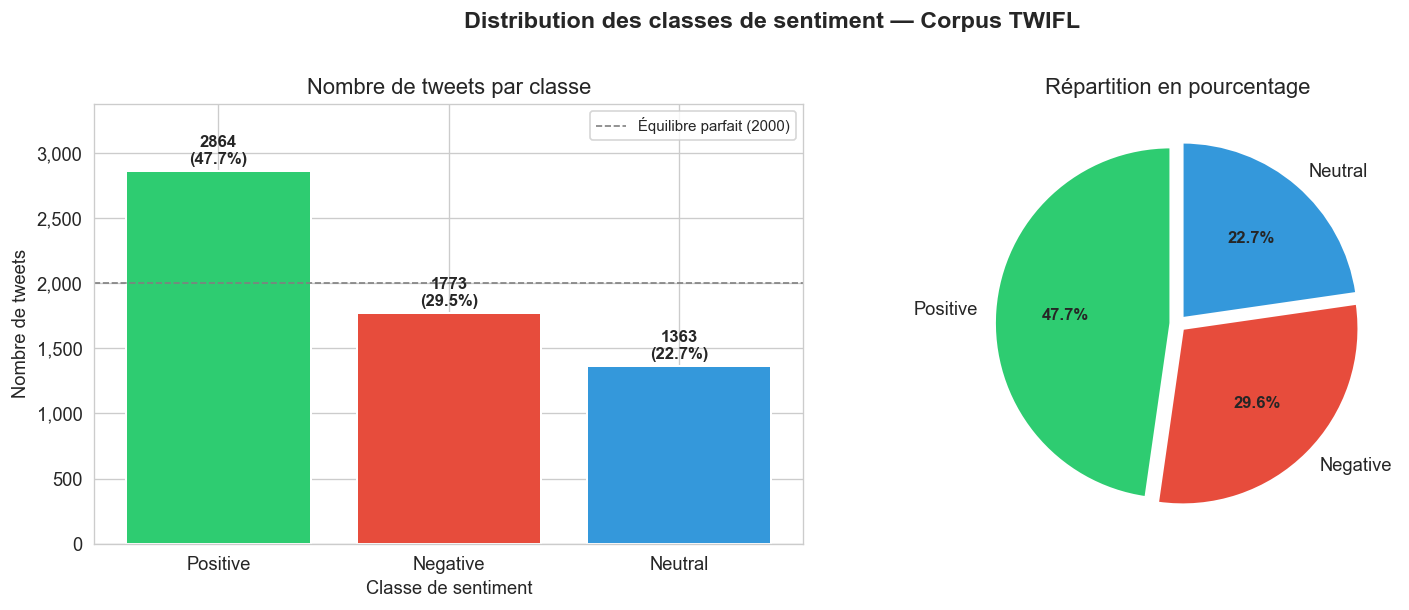

Figure sauvegardée : distribution_classes.png


In [15]:
# Visualisation : Bar chart + Pie chart de la distribution des classes
COLORS = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#3498db'}
color_list = [COLORS.get(c, '#95a5a6') for c in class_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribution des classes de sentiment — Corpus TWIFL', fontsize=14, fontweight='bold', y=1.01)

# --- Bar chart ---
bars = axes[0].bar(class_counts.index, class_counts.values, color=color_list, edgecolor='white', linewidth=1.2)
axes[0].set_title('Nombre de tweets par classe')
axes[0].set_xlabel('Classe de sentiment')
axes[0].set_ylabel('Nombre de tweets')
for bar, count, pct in zip(bars, class_counts.values, class_pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max_class * 1.18)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Ligne de référence pour l'équilibre parfait
equilibre = len(df_clean) / 3
axes[0].axhline(equilibre, color='gray', linestyle='--', linewidth=1, label=f'Équilibre parfait ({int(equilibre)})')
axes[0].legend(fontsize=9)

# --- Pie chart ---
wedges, texts, autotexts = axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    colors=color_list,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.04] * len(class_counts),
    shadow=False,
    wedgeprops=dict(linewidth=1.5, edgecolor='white')
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[1].set_title('Répartition en pourcentage')

plt.tight_layout()
plt.savefig('distribution_classes.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure sauvegardée : distribution_classes.png")

## 1.3 Analyse linguistique des tweets

In [16]:
TEXT_COL = "Post"

print(f"✅ Colonne texte utilisée : '{TEXT_COL}'")

if len(df_clean) > 0:
    print("Exemple :")
    print(df_clean[TEXT_COL].iloc[0])
else:
    print("⚠️ DataFrame vide")

✅ Colonne texte utilisée : 'Post'
Exemple :
@gamehacker080 @WaellAmeer @Kempa2010 @omeralbaze @ma7een تم


In [17]:
# --- Fonctions d'analyse linguistique ---

def count_words(text):
    """Nombre de mots (tokens séparés par espace)."""
    if pd.isna(text):
        return 0
    return len(str(text).split())

def count_chars(text):
    """Nombre de caractères (hors espaces)."""
    if pd.isna(text):
        return 0
    return len(str(text).replace(' ', ''))

def has_emoji(text):
    """Retourne True si le tweet contient au moins un emoji."""
    if pd.isna(text):
        return False
    return bool(emoji.emoji_count(str(text)))

# Heuristique : code-switching = présence de mots latins dans un texte majoritairement arabe
FRENCH_PATTERN = re.compile(r'\b[a-zA-Z]{2,}\b')
ARABIC_PATTERN  = re.compile(r'[\u0600-\u06FF]')

def has_code_switching(text):
    """Détecte la présence de mots latins + caractères arabes dans le même tweet."""
    if pd.isna(text):
        return False
    t = str(text)
    has_arabic = bool(ARABIC_PATTERN.search(t))
    has_latin  = bool(FRENCH_PATTERN.search(t))
    return has_arabic and has_latin

print("Fonctions d'analyse définies.")

Fonctions d'analyse définies.


In [18]:
# Application des fonctions
df_clean['nb_mots']         = df_clean[TEXT_COL].apply(count_words)
df_clean['nb_chars']        = df_clean[TEXT_COL].apply(count_chars)
df_clean['contient_emoji']  = df_clean[TEXT_COL].apply(has_emoji)
df_clean['code_switching']  = df_clean[TEXT_COL].apply(has_code_switching)

print(f"Proportion de tweets avec emoji       : {df_clean['contient_emoji'].mean()*100:.1f}%")
print(f"Proportion de tweets avec code-switching : {df_clean['code_switching'].mean()*100:.1f}%")

Proportion de tweets avec emoji       : 21.6%
Proportion de tweets avec code-switching : 26.6%


In [19]:
# Analyse de la colonne 'lang' (langue détectée)
if 'lang' in df_clean.columns:
    lang_counts = df_clean['lang'].value_counts()
    total = len(df_clean)
    print("Distribution des langues détectées (colonne 'lang') :")
    print("─" * 40)
    for lang, cnt in lang_counts.items():
        print(f"  {str(lang):<10} : {cnt:>5} tweets  ({cnt/total*100:.1f}%)")
    print("─" * 40)
    print(f"  TOTAL      : {total} tweets")
    
    print("\n📌 Note : les tweets de langue 'und' (indéterminée) sont conservés.")
    print("   Leur contenu est souvent en Arabizi ou en arabe dialectal non reconnu.")
else:
    print("⚠️  Pas de colonne 'lang' dans ce dataset.")

Distribution des langues détectées (colonne 'lang') :
────────────────────────────────────────
  ar         :  2462 tweets  (41.0%)
  und        :  1244 tweets  (20.7%)
  fr         :  1110 tweets  (18.5%)
  en         :   733 tweets  (12.2%)
  es         :    94 tweets  (1.6%)
  in         :    87 tweets  (1.5%)
  tr         :    52 tweets  (0.9%)
  ht         :    45 tweets  (0.8%)
  pt         :    34 tweets  (0.6%)
  tl         :    22 tweets  (0.4%)
  it         :    20 tweets  (0.3%)
  bn         :    18 tweets  (0.3%)
  ca         :    17 tweets  (0.3%)
  de         :    10 tweets  (0.2%)
  et         :     8 tweets  (0.1%)
  nl         :     6 tweets  (0.1%)
  hi         :     4 tweets  (0.1%)
  fi         :     4 tweets  (0.1%)
  lv         :     4 tweets  (0.1%)
  ro         :     4 tweets  (0.1%)
  eu         :     3 tweets  (0.1%)
  cs         :     3 tweets  (0.1%)
  da         :     3 tweets  (0.1%)
  ja         :     3 tweets  (0.1%)
  zh         :     2 tweets  (0.0%)
 

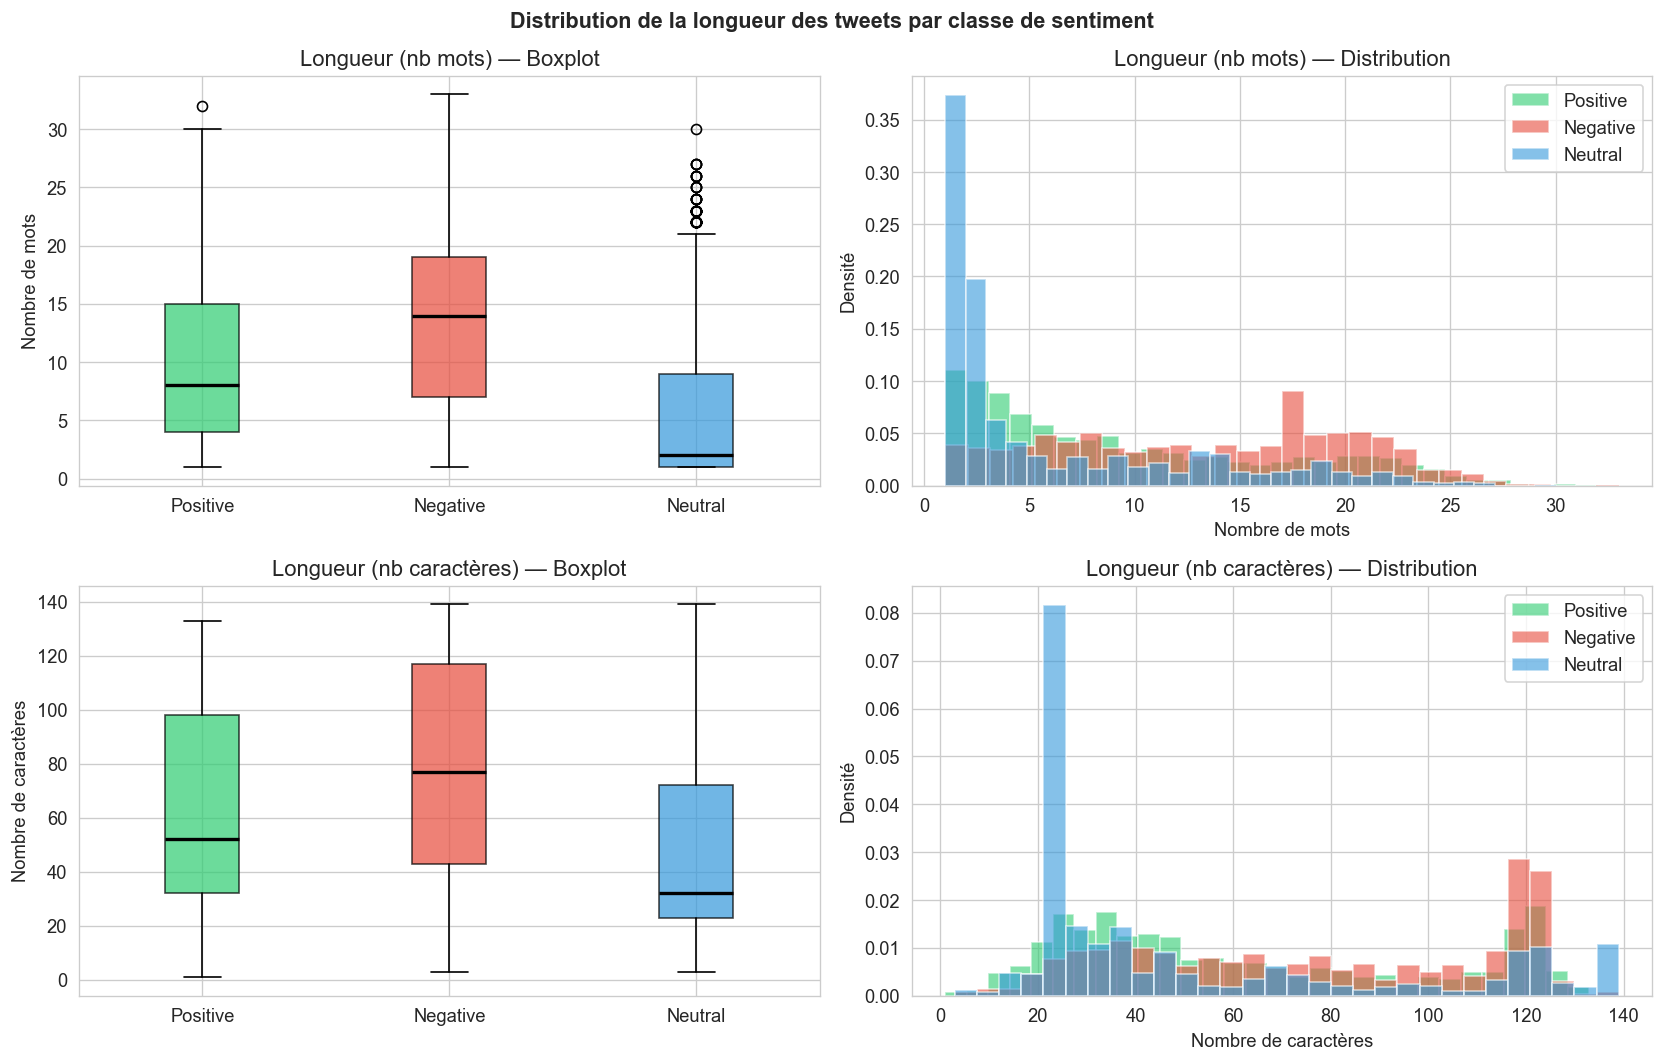

Figure sauvegardée : longueur_tweets.png


In [20]:
# Visualisation : distribution de la longueur (mots et caractères) par classe
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Distribution de la longueur des tweets par classe de sentiment', fontsize=13, fontweight='bold')

classes = df_clean['Polarity Class'].unique()

# --- Boxplot : nombre de mots ---
data_mots = [df_clean[df_clean['Polarity Class'] == c]['nb_mots'].values for c in ['Positive', 'Negative', 'Neutral']]
bp1 = axes[0, 0].boxplot(data_mots, labels=['Positive', 'Negative', 'Neutral'],
                          patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp1['boxes'], [COLORS['Positive'], COLORS['Negative'], COLORS['Neutral']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 0].set_title('Longueur (nb mots) — Boxplot')
axes[0, 0].set_ylabel('Nombre de mots')

# --- Histogramme : nombre de mots ---
for cls in ['Positive', 'Negative', 'Neutral']:
    axes[0, 1].hist(df_clean[df_clean['Polarity Class'] == cls]['nb_mots'],
                    bins=30, alpha=0.6, label=cls, color=COLORS[cls], density=True)
axes[0, 1].set_title('Longueur (nb mots) — Distribution')
axes[0, 1].set_xlabel('Nombre de mots')
axes[0, 1].set_ylabel('Densité')
axes[0, 1].legend()

# --- Boxplot : nombre de caractères ---
data_chars = [df_clean[df_clean['Polarity Class'] == c]['nb_chars'].values for c in ['Positive', 'Negative', 'Neutral']]
bp2 = axes[1, 0].boxplot(data_chars, labels=['Positive', 'Negative', 'Neutral'],
                          patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], [COLORS['Positive'], COLORS['Negative'], COLORS['Neutral']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_title('Longueur (nb caractères) — Boxplot')
axes[1, 0].set_ylabel('Nombre de caractères')

# --- Histogramme : nombre de caractères ---
for cls in ['Positive', 'Negative', 'Neutral']:
    axes[1, 1].hist(df_clean[df_clean['Polarity Class'] == cls]['nb_chars'],
                    bins=30, alpha=0.6, label=cls, color=COLORS[cls], density=True)
axes[1, 1].set_title('Longueur (nb caractères) — Distribution')
axes[1, 1].set_xlabel('Nombre de caractères')
axes[1, 1].set_ylabel('Densité')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('longueur_tweets.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure sauvegardée : longueur_tweets.png")

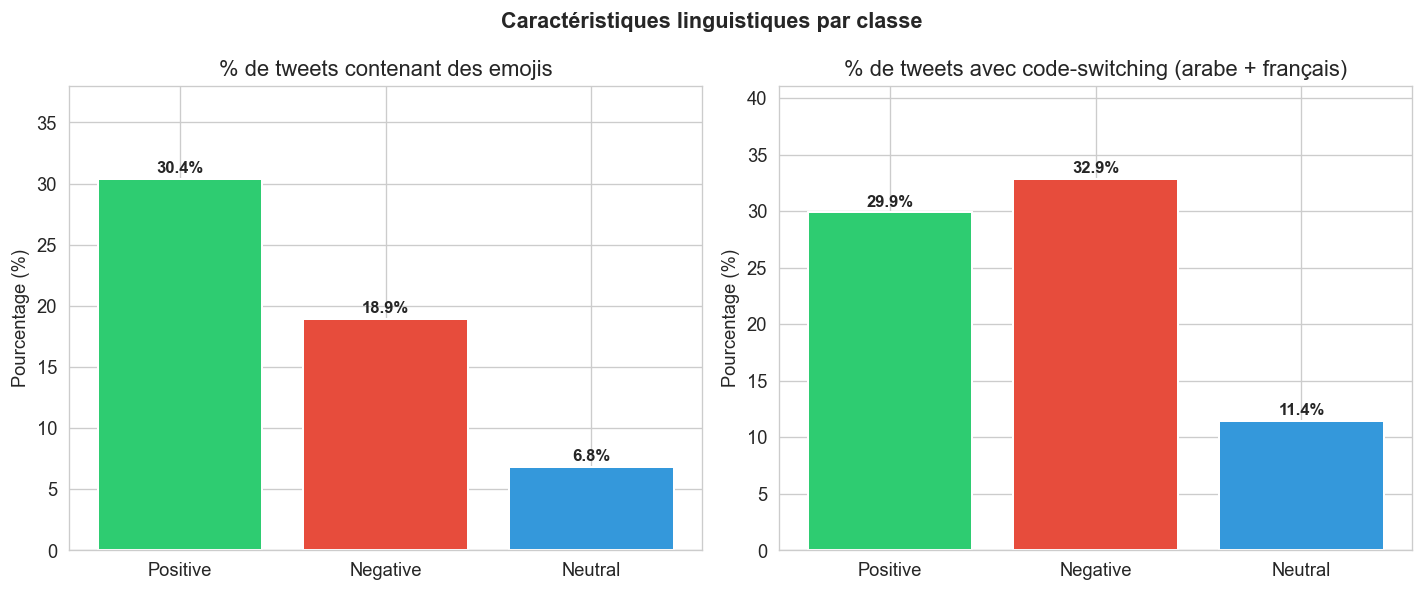

Figure sauvegardée : linguistique_classes.png


In [21]:
# Proportion d'emojis et de code-switching par classe
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Caractéristiques linguistiques par classe', fontsize=13, fontweight='bold')

# Emoji par classe
emoji_by_class = df_clean.groupby('Polarity Class')['contient_emoji'].mean() * 100
emoji_by_class = emoji_by_class.reindex(['Positive', 'Negative', 'Neutral'])
axes[0].bar(emoji_by_class.index, emoji_by_class.values,
            color=[COLORS[c] for c in emoji_by_class.index], edgecolor='white', linewidth=1.2)
for i, (cls, val) in enumerate(emoji_by_class.items()):
    axes[0].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('% de tweets contenant des emojis')
axes[0].set_ylabel('Pourcentage (%)')
axes[0].set_ylim(0, emoji_by_class.max() * 1.25)

# Code-switching par classe
cs_by_class = df_clean.groupby('Polarity Class')['code_switching'].mean() * 100
cs_by_class = cs_by_class.reindex(['Positive', 'Negative', 'Neutral'])
axes[1].bar(cs_by_class.index, cs_by_class.values,
            color=[COLORS[c] for c in cs_by_class.index], edgecolor='white', linewidth=1.2)
for i, (cls, val) in enumerate(cs_by_class.items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('% de tweets avec code-switching (arabe + français)')
axes[1].set_ylabel('Pourcentage (%)')
axes[1].set_ylim(0, cs_by_class.max() * 1.25)

plt.tight_layout()
plt.savefig('linguistique_classes.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure sauvegardée : linguistique_classes.png")

## 1.4 Nuages de mots (WordCloud) par classe

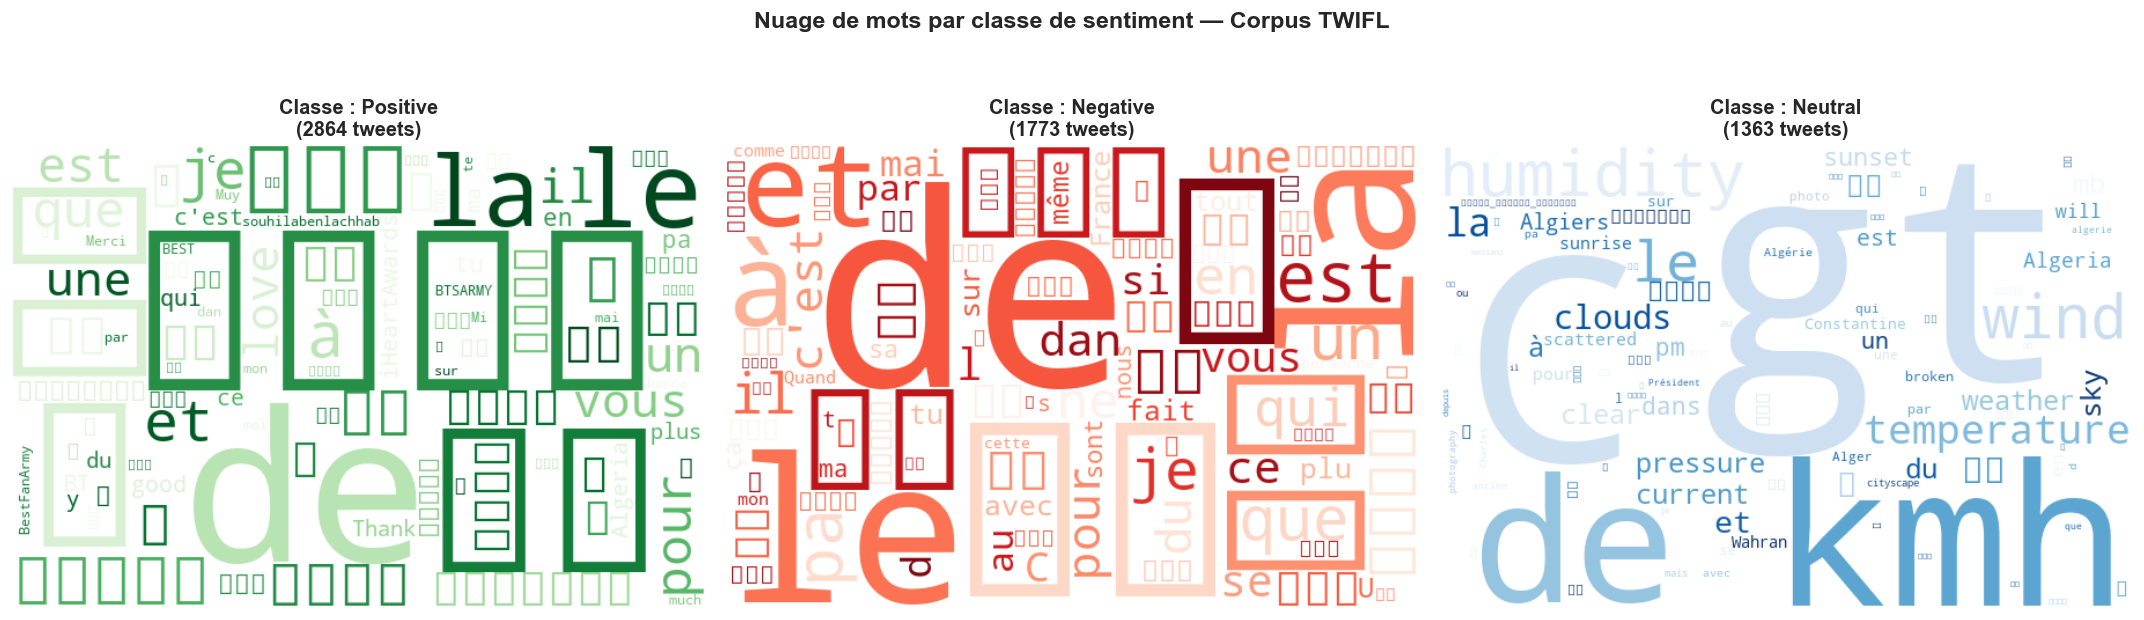

Figure sauvegardée : wordclouds.png

📌 Note : si le texte arabe apparaît en tofu (carrés), ajouter un font_path vers une
   police arabe (ex: Amiri, Scheherazade) dans le paramètre WordCloud.


In [22]:
# Nettoyage minimal pour le WordCloud (URLs, mentions, chiffres)
def clean_for_wordcloud(text):
    if pd.isna(text):
        return ''
    t = str(text)
    t = re.sub(r'https?://\S+', '', t)        # URLs
    t = re.sub(r'@\w+', '', t)                # Mentions
    t = re.sub(r'#(\w+)', r'\1', t)           # Hashtags → garder le mot
    t = re.sub(r'[0-9]+', '', t)              # Chiffres
    t = re.sub(r'[\u200c-\u200f]', '', t)    # Caractères de direction RTL invisibles
    return t.strip()

# Générer un WordCloud par classe
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Nuage de mots par classe de sentiment — Corpus TWIFL', fontsize=14, fontweight='bold')

WC_COLORS = {'Positive': 'Greens', 'Negative': 'Reds', 'Neutral': 'Blues'}

for ax, cls in zip(axes, ['Positive', 'Negative', 'Neutral']):
    texts = df_clean[df_clean['Polarity Class'] == cls][TEXT_COL].apply(clean_for_wordcloud)
    corpus_text = ' '.join(texts.tolist())
    
    if len(corpus_text.strip()) == 0:
        ax.text(0.5, 0.5, 'Aucun texte disponible', ha='center', va='center', transform=ax.transAxes)
    else:
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap=WC_COLORS[cls],
            max_words=100,
            collocations=False,
            # font_path='/path/to/arabic/font.ttf'  # Décommentez si texte arabe illisible
        ).generate(corpus_text)
        ax.imshow(wc, interpolation='bilinear')
    
    ax.axis('off')
    ax.set_title(f'Classe : {cls}\n({class_counts.get(cls, 0)} tweets)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('wordclouds.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure sauvegardée : wordclouds.png")
print("\n📌 Note : si le texte arabe apparaît en tofu (carrés), ajouter un font_path vers une")
print("   police arabe (ex: Amiri, Scheherazade) dans le paramètre WordCloud.")

## 1.5 Tableau de statistiques obligatoire (rapport)

In [23]:
# Construction du tableau récapitulatif demandé dans le rapport
stats_rows = []

for cls in ['Positive', 'Negative', 'Neutral']:
    subset = df_clean[df_clean['Polarity Class'] == cls]
    nb = len(subset)
    pct = nb / len(df_clean) * 100
    moy_mots = subset['nb_mots'].mean()
    moy_chars = subset['nb_chars'].mean()
    pct_emoji = subset['contient_emoji'].mean() * 100
    pct_cs    = subset['code_switching'].mean() * 100
    stats_rows.append({
        'Classe': cls,
        'Nb exemples': nb,
        '% du corpus': f'{pct:.1f}%',
        'Moy. mots': f'{moy_mots:.1f}',
        'Moy. caractères': f'{moy_chars:.1f}',
        '% emojis': f'{pct_emoji:.1f}%',
        '% code-switching': f'{pct_cs:.1f}%',
    })

# Ligne TOTAL
stats_rows.append({
    'Classe': 'TOTAL',
    'Nb exemples': len(df_clean),
    '% du corpus': '100%',
    'Moy. mots': f"{df_clean['nb_mots'].mean():.1f}",
    'Moy. caractères': f"{df_clean['nb_chars'].mean():.1f}",
    '% emojis': f"{df_clean['contient_emoji'].mean()*100:.1f}%",
    '% code-switching': f"{df_clean['code_switching'].mean()*100:.1f}%",
})

stats_df = pd.DataFrame(stats_rows)
print("=" * 80)
print("TABLEAU DE STATISTIQUES — À INCLURE DANS LE RAPPORT")
print("=" * 80)
print(stats_df.to_string(index=False))
print("=" * 80)

# Sauvegarde en CSV
stats_df.to_csv('tableau_statistiques_EDA.csv', index=False)
print("\nTableau sauvegardé : tableau_statistiques_EDA.csv")

TABLEAU DE STATISTIQUES — À INCLURE DANS LE RAPPORT
  Classe  Nb exemples % du corpus Moy. mots Moy. caractères % emojis % code-switching
Positive         2864       47.7%       9.9            63.1    30.4%            29.9%
Negative         1773       29.5%      13.5            77.6    18.9%            32.9%
 Neutral         1363       22.7%       5.7            51.8     6.8%            11.4%
   TOTAL         6000        100%      10.0            64.8    21.6%            26.6%

Tableau sauvegardé : tableau_statistiques_EDA.csv


## 1.6 Analyse des tweets courts et tweets 'und'

In [24]:
# Tweets très courts (1 ou 2 mots)
tres_courts = df_clean[df_clean['nb_mots'] <= 2]
print(f"Tweets très courts (≤ 2 mots) : {len(tres_courts)} ({len(tres_courts)/len(df_clean)*100:.1f}%)")
print("\nExemples de tweets très courts :")
print(tres_courts[[TEXT_COL, 'Polarity Class', 'nb_mots']].head(10).to_string(index=False))

print("\n📌 Décision à documenter dans le rapport :")
print("   → Ces tweets très courts seront CONSERVÉS si leur texte est informatif.")
print("   → Ils seront SUPPRIMÉS uniquement s'ils sont vides après nettoyage (URLs seules, etc.).")

Tweets très courts (≤ 2 mots) : 1151 (19.2%)

Exemples de tweets très courts :
                                                                                                                                        Post Polarity Class  nb_mots
                                                                                                                     https://t.co/GvubnBx8ET        Neutral        1
 🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍♀️🤦‍… https://t.co/HbmutLGs5c       Negative        2
bec14c76ec06281720a04677acc70297f766d7dcad9d3809ac9253d7c139393fe5712ddacc7c6acfee1d8e4896b79c8041f38b2d05a4dca1622… https://t.co/8zHqgoaJ6f        Neutral        2
                                                                                                      @jiji05659865  https://t.co/m6hYiEyh7G        Neutral        2
                                                                                                

In [25]:
# Tweets en langue 'und'
if 'lang' in df_clean.columns:
    und_tweets = df_clean[df_clean['lang'] == 'und']
    print(f"Tweets en langue 'und' : {len(und_tweets)} ({len(und_tweets)/len(df_clean)*100:.1f}%)")
    print("\nExemples de tweets 'und' :")
    print(und_tweets[[TEXT_COL, 'Polarity Class']].head(10).to_string(index=False))
    print("\n📌 Ces tweets sont CONSERVÉS : ils contiennent souvent de l'Arabizi non détectable.")
else:
    print("Pas de colonne 'lang' disponible.")

Tweets en langue 'und' : 1244 (20.7%)

Exemples de tweets 'und' :
                                                                                                                                       Post Polarity Class
                                                                                  @SRKFC1 @iamsrk @gaurikhan 💖💖💖💖💖💖 https://t.co/0DwWeTr7ZK       Positive
                                                            @DabbooRatnani @iamsrk @ManishaDRatnani @Dabboo 😕😘😘😘😘😘😘 https://t.co/Xt0HqaUrKU       Negative
                                                                                                                    https://t.co/GvubnBx8ET        Neutral
                                                                                         @AmoonMua @juniorbachchan  https://t.co/3jV3j1DX6A        Neutral
                                                           @ChennaiyinFC @CssTru @juniorbachchan ⚽️⚽️⚽️⚽️🇮🇳🇮🇳🇮🇳🇮🇳🇮🇳 https://t.co/Qsq3MJi5wE       Positive
🤦‍♀️

## 1.7 Sauvegarde du DataFrame nettoyé

In [26]:
# Sauvegarde du dataframe avec les features calculées (pour l'étape 2)
df_clean.to_csv('twifl_explored.csv', index=False)
print(f"Dataset exploré sauvegardé : twifl_explored.csv ({len(df_clean)} tweets)")

print("\n=" * 50)
print("RÉSUMÉ DE L'ÉTAPE 1")
print("=" * 50)
print(f"  Tweets chargés        : {len(df)}")
print(f"  Tweets conservés      : {len(df_clean)}")
print(f"  Ratio de déséquilibre : {imbalance_ratio:.2f}x")
print(f"  Corpus                : {niveau}")
print(f"  Figures sauvegardées  : distribution_classes.png, longueur_tweets.png,")
print(f"                          linguistique_classes.png, wordclouds.png")
print(f"  Tableau sauvegardé    : tableau_statistiques_EDA.csv")
print("\n→ Prêt pour l'Étape 2 : Prétraitement spécifique au dialecte algérien.")

Dataset exploré sauvegardé : twifl_explored.csv (6000 tweets)

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
RÉSUMÉ DE L'ÉTAPE 1
  Tweets chargés        : 6000
  Tweets conservés      : 6000
  Ratio de déséquilibre : 2.10x
  Corpus                : MODÉRÉMENT déséquilibré
  Figures sauvegardées  : distribution_classes.png, longueur_tweets.png,
                          linguistique_classes.png, wordclouds.png
  Tableau sauvegardé    : tableau_statistiques_EDA.csv

→ Prêt pour l'Étape 2 : Prétraitement spécifique au dialecte algérien.
